In [1]:
!pip install pyspark

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AnalisisOlistPySpark") \
    .getOrCreate()

print("Spark version:", spark.version)

Spark version: 4.0.3


In [3]:
from google.colab import files
uploaded = files.upload()

Saving olist_customers_dataset.csv to olist_customers_dataset.csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv
Saving olist_order_payments_dataset.csv to olist_order_payments_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv


In [4]:
orders = spark.read.csv("olist_orders_dataset.csv", header=True, inferSchema=True)
order_items = spark.read.csv("olist_order_items_dataset.csv", header=True, inferSchema=True)
customers = spark.read.csv("olist_customers_dataset.csv", header=True, inferSchema=True)
payments = spark.read.csv("olist_order_payments_dataset.csv", header=True, inferSchema=True)

print("Orders:", orders.count(), "filas")
print("Order items:", order_items.count(), "filas")
print("Customers:", customers.count(), "filas")
print("Payments:", payments.count(), "filas")

Orders: 99441 filas
Order items: 112650 filas
Customers: 99441 filas
Payments: 103886 filas


In [5]:
orders.printSchema()

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)



In [6]:
orders.show(5)

+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|            order_id|         customer_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|e481f51cbdc54678b...|9ef432eb625129730...|   delivered|     2017-10-02 10:56:33|2017-10-02 11:07:15|         2017-10-04 19:55:00|          2017-10-10 21:25:13|          2017-10-18 00:00:00|
|53cdb2fc8bc7dce0b...|b0830fb4747a6c6d2...|   delivered|     2018-07-24 20:41:37|2018-07-26 03:24:27|         2018-07-26 14:31:00|          2018-08-07 15:27:45|          2018-08-13 00:00:00|
|47770eb9100c2d0c4...|41ce2a54c0b03bf34...|  

In [7]:
orders_customers = orders.join(customers, on="customer_id", how="inner")
orders_customers.select("order_id", "customer_id", "customer_state", "order_status").show(5)

+--------------------+--------------------+--------------+------------+
|            order_id|         customer_id|customer_state|order_status|
+--------------------+--------------------+--------------+------------+
|e481f51cbdc54678b...|9ef432eb625129730...|            SP|   delivered|
|53cdb2fc8bc7dce0b...|b0830fb4747a6c6d2...|            BA|   delivered|
|47770eb9100c2d0c4...|41ce2a54c0b03bf34...|            GO|   delivered|
|949d5b44dbf5de918...|f88197465ea7920ad...|            RN|   delivered|
|ad21c59c0840e6cb8...|8ab97904e6daea886...|            SP|   delivered|
+--------------------+--------------------+--------------+------------+
only showing top 5 rows


In [8]:
from pyspark.sql import functions as F

pedidos_por_estado = orders_customers.groupBy("customer_state") \
    .agg(F.count("order_id").alias("total_pedidos")) \
    .orderBy(F.desc("total_pedidos"))

pedidos_por_estado.show(10)

+--------------+-------------+
|customer_state|total_pedidos|
+--------------+-------------+
|            SP|        41746|
|            RJ|        12852|
|            MG|        11635|
|            RS|         5466|
|            PR|         5045|
|            SC|         3637|
|            BA|         3380|
|            DF|         2140|
|            ES|         2033|
|            GO|         2020|
+--------------+-------------+
only showing top 10 rows


In [9]:
ventas_completas = orders_customers.join(payments, on="order_id", how="inner")

ingresos_por_estado = ventas_completas.groupBy("customer_state") \
    .agg(F.round(F.sum("payment_value"), 2).alias("ingresos_totales")) \
    .orderBy(F.desc("ingresos_totales"))

ingresos_por_estado.show(10)

+--------------+----------------+
|customer_state|ingresos_totales|
+--------------+----------------+
|            SP|      5998226.96|
|            RJ|      2144379.69|
|            MG|      1872257.26|
|            RS|       890898.54|
|            PR|       811156.38|
|            SC|       623086.43|
|            BA|       616645.82|
|            DF|       355141.08|
|            GO|       350092.31|
|            ES|       325967.55|
+--------------+----------------+
only showing top 10 rows


In [10]:
from pyspark.sql.window import Window

gasto_cliente = ventas_completas.groupBy("customer_unique_id", "customer_state") \
    .agg(F.round(F.sum("payment_value"), 2).alias("gasto_total"))

ventana = Window.partitionBy("customer_state").orderBy(F.desc("gasto_total"))

ranking_clientes = gasto_cliente.withColumn("ranking_en_su_estado", F.rank().over(ventana))

ranking_clientes.orderBy("customer_state", "ranking_en_su_estado").show(15)

+--------------------+--------------+-----------+--------------------+
|  customer_unique_id|customer_state|gasto_total|ranking_en_su_estado|
+--------------------+--------------+-----------+--------------------+
|62a459e5629b03dd7...|            AC|     1251.7|                   1|
|086d6b5b5ba195a91...|            AC|     995.18|                   2|
|3947ca729a860c522...|            AC|     905.93|                   3|
|3e5c928acf49c4b95...|            AC|     861.26|                   4|
|28989ef45087c96e5...|            AC|     723.15|                   5|
|12e92c0f870fc6941...|            AC|     646.44|                   6|
|22c739518f5240ffd...|            AC|      618.6|                   7|
|0845d810b482f4d46...|            AC|     595.49|                   8|
|c6bc2bf4b75f3f9da...|            AC|     591.88|                   9|
|2ec67750cd5b98553...|            AC|     548.93|                  10|
|5dbba6c01268a8ad4...|            AC|     496.87|                  11|
|8c792

In [11]:
print("Número de particiones del DataFrame:", ventas_completas.rdd.getNumPartitions())

Número de particiones del DataFrame: 2


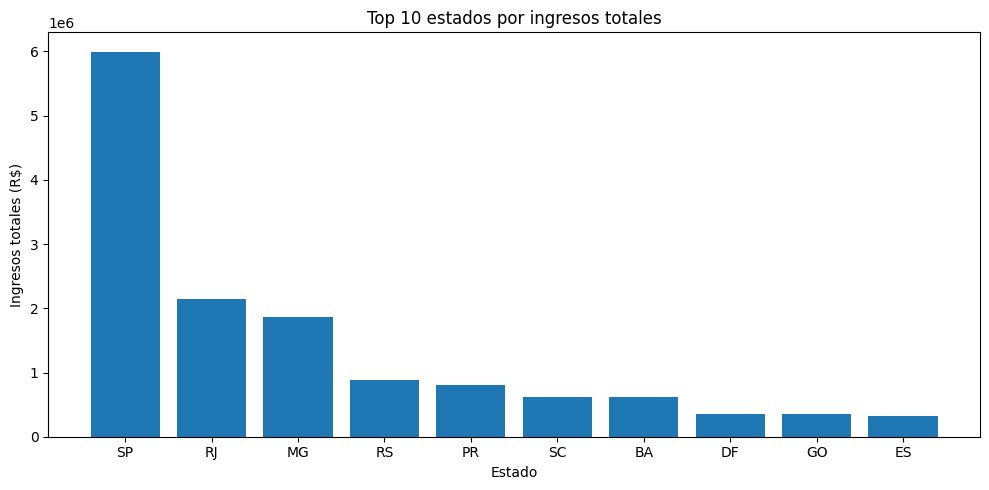

In [12]:
import matplotlib.pyplot as plt

top10_estados = ingresos_por_estado.limit(10).toPandas()

plt.figure(figsize=(10,5))
plt.bar(top10_estados['customer_state'], top10_estados['ingresos_totales'])
plt.title('Top 10 estados por ingresos totales')
plt.xlabel('Estado')
plt.ylabel('Ingresos totales (R$)')
plt.tight_layout()
plt.savefig('ingresos_por_estado.png')
plt.show()

In [13]:
from google.colab import files
files.download('ingresos_por_estado.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>